# Exploratory Data Analysis on a Cars Dataset

**Project Title:** Automobile Data Exploratory Data Analysis
**Student Name:** [Your Name]
**Batch:** [Your Batch]
**Date:** [Current Date]
**Dataset Source:** Seaborn 'mpg' built-in dataset (StatLib library at Carnegie Mellon University)

## Objective
The purpose of this EDA is to understand the dataset, improve data quality, identify patterns and outliers, and communicate useful insights through clear visualisations.

**Main Questions Explored:**
1. Which origins/brands are most common?
2. How is vehicle efficiency (MPG) distributed?
3. How does vehicle age (model year) relate to MPG?
4. Does weight appear to influence MPG?
5. Which features are strongly correlated?
6. Where are the important outliers in engine power?

## 1. Dataset Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = sns.load_dataset('mpg')

print(f"Dataset Dimensions (Rows, Columns): {df.shape}")
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
df.head()

Dataset Dimensions (Rows, Columns): (398, 9)

Column Names: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'name']

Data Types:
 mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
name             object
dtype: object


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


### Separate Numerical and Categorical Variables

In [2]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical Columns: {num_cols}")
print(f"Categorical Columns: {cat_cols}")

Numerical Columns: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
Categorical Columns: ['origin', 'name']


## 2. Data Quality and Cleaning

In [3]:
initial_rows = len(df)

# Check Duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")

# Check Missing Values
print("\nMissing Values before cleaning:\n", df.isnull().sum()[df.isnull().sum() > 0])

# Clean Data: Drop duplicates if any
df_clean = df.drop_duplicates().copy()

# Clean Data: Treat missing values (imputing horsepower with median as it's a numeric property)
df_clean['horsepower'] = df_clean['horsepower'].fillna(df_clean['horsepower'].median())

# Clean Data: Feature Engineering (Extract brand from name to fix inconsistent labels)
df_clean['brand'] = df_clean['name'].apply(lambda x: x.split()[0])

print(f"\nDataset size before cleaning: {initial_rows} rows")
print(f"Dataset size after cleaning: {len(df_clean)} rows")
print("Remaining missing values:", df_clean.isnull().sum().sum())

Duplicate Rows: 0

Missing Values before cleaning:
 horsepower    6
dtype: int64

Dataset size before cleaning: 398 rows
Dataset size after cleaning: 398 rows
Remaining missing values: 0


**Cleaning Decisions:** Missing horsepower values were imputed using the median to avoid dropping useful records, as horsepower is typically right-skewed. The 'brand' feature was extracted from the 'name' column to create a more consistent categorical grouping.

## 3. Descriptive Analysis

In [4]:
print("--- Numerical Summary ---")
display(df_clean.describe())

print("\n--- Categorical Summary ---")
display(df_clean.describe(include=['object']))

--- Numerical Summary ---


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.304020,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.222625,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000



--- Categorical Summary ---


,origin,name,brand
count,398,398,398
unique,3,305,37
top,usa,ford pinto,ford
freq,249,6,51


**Observation:** The average MPG is ~23.5, with weights ranging heavily from 1,613 to 5,140 lbs. 'Ford' appears as the most frequent top-level brand label.

## 4. Visual EDA

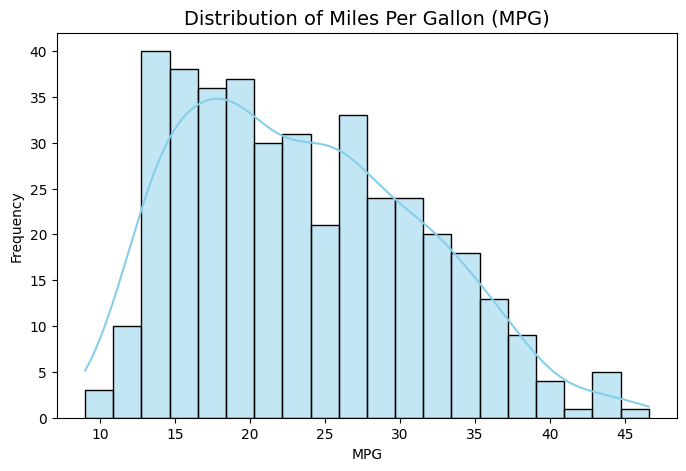

In [5]:
# Chart 1: Histogram (Univariate)
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['mpg'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Miles Per Gallon (MPG)', fontsize=14)
plt.xlabel('MPG')
plt.ylabel('Frequency')
plt.show()

**Observation 1:** The MPG distribution is slightly right-skewed, with most vehicles clustering between 15 and 25 MPG. Highly efficient cars (>35 MPG) are rare.

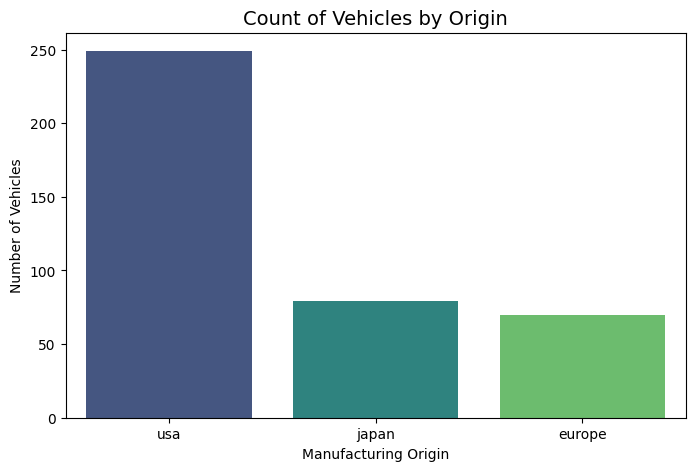

In [6]:
# Chart 2: Count Plot (Univariate Categorical)
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='origin', palette='viridis')
plt.title('Count of Vehicles by Origin', fontsize=14)
plt.xlabel('Manufacturing Origin')
plt.ylabel('Number of Vehicles')
plt.show()

**Observation 2:** The dataset is dominated by USA-manufactured vehicles, which account for more than half of the total records, followed by Japan and Europe.

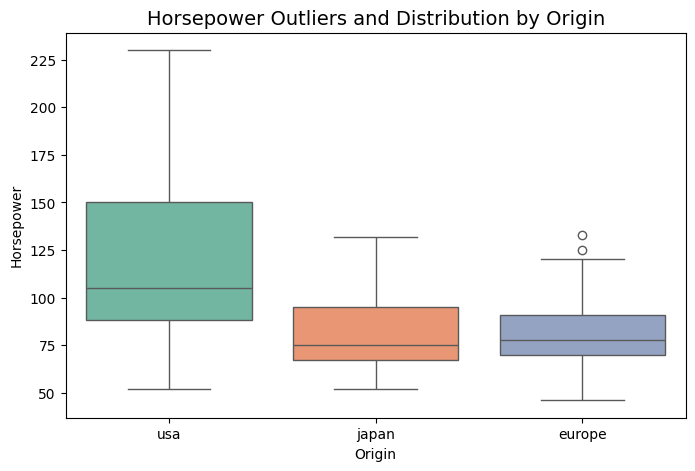

In [7]:
# Chart 3: Box Plot (Outlier Detection)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='origin', y='horsepower', palette='Set2')
plt.title('Horsepower Outliers and Distribution by Origin', fontsize=14)
plt.xlabel('Origin')
plt.ylabel('Horsepower')
plt.show()

**Observation 3:** USA cars have the highest median horsepower and a much wider spread, including several high-end outliers exceeding 200 HP. European and Japanese cars are lower-powered and more tightly grouped.

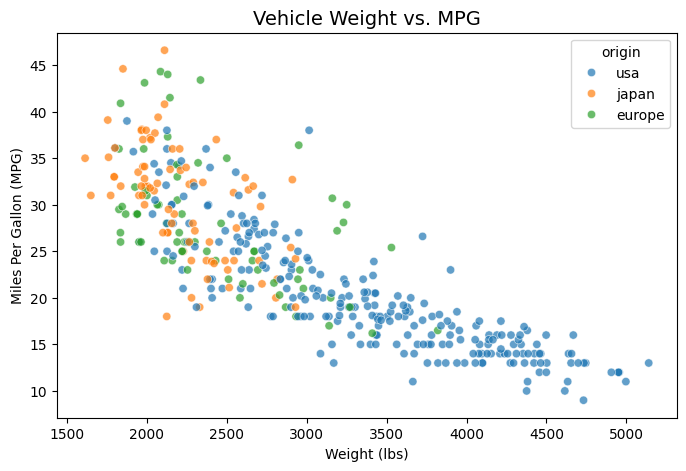

In [8]:
# Chart 4: Scatter Plot (Bivariate)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='weight', y='mpg', hue='origin', alpha=0.7)
plt.title('Vehicle Weight vs. MPG', fontsize=14)
plt.xlabel('Weight (lbs)')
plt.ylabel('Miles Per Gallon (MPG)')
plt.show()

**Observation 4:** There is a strong negative, non-linear relationship between weight and MPG. Heavier vehicles (mostly from the USA) suffer a severe penalty in fuel efficiency.

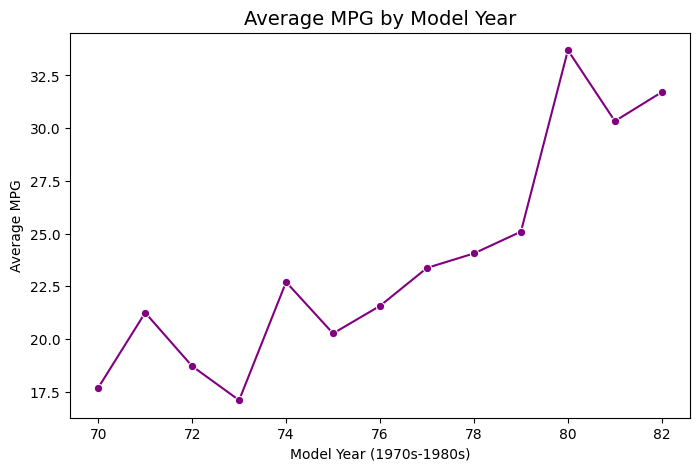

In [9]:
# Chart 5: Line Plot (Bivariate Trend)
plt.figure(figsize=(8, 5))
sns.lineplot(data=df_clean, x='model_year', y='mpg', ci=None, marker='o', color='purple')
plt.title('Average MPG by Model Year', fontsize=14)
plt.xlabel('Model Year (1970s-1980s)')
plt.ylabel('Average MPG')
plt.show()

**Observation 5:** Vehicle fuel efficiency improved significantly over time, climbing steadily from an average of ~18 MPG in 1970 to over 30 MPG by 1982, likely due to changing regulations and technology.

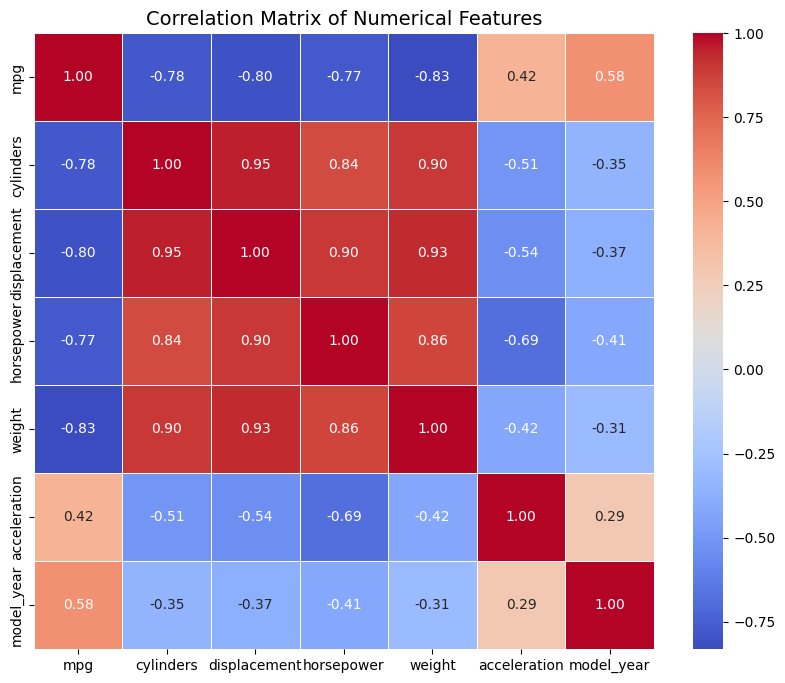

In [10]:
# Chart 6: Heatmap (Multivariate Correlation)
plt.figure(figsize=(10, 8))
corr = df_clean[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=14)
plt.show()

**Observation 6:** MPG is highly negatively correlated with weight (-0.83), displacement (-0.80), and cylinders (-0.78). Meanwhile, displacement and weight are nearly perfectly correlated (+0.93).

## 5. Key Findings

1. **Weight is the strongest detractor of fuel efficiency:** The correlation of -0.83 indicates that as car weight increases, MPG plummets rapidly.
2. **USA manufactures heavier, powerful cars:** Vehicles originating from the USA consistently show higher horsepower, greater weight, and consequently, the lowest MPG among the regions.
3. **Efficiency improved over the decade:** From 1970 to 1982, the average MPG of manufactured vehicles increased substantially, shifting industry norms.
4. **Engine size redundancy:** Cylinders, displacement, and weight are heavily correlated with each other (all >0.85). In predictive modeling, keeping all three might cause multicollinearity.
5. **High-power outliers:** A few USA vehicles feature horsepower well above the upper fence (>200 HP). These represent specialized performance vehicles distinct from the typical consumer commuter car.

**Limitations of the Dataset:**
- The data only spans 1970-1982, meaning it doesn't reflect modern engine efficiencies, EVs, or hybrid vehicles.
- The dataset is heavily imbalanced toward USA-origin vehicles, which might skew aggregate analyses.

## 6. Conclusion
This EDA successfully cleaned and analyzed a historical vehicle dataset. Missing horsepower values were addressed, and consistent brand names were extracted. We discovered that fuel efficiency is heavily dictated by physical constraints (weight and displacement) and saw a clear historical trend toward more efficient vehicles. Future analysis could involve clustering vehicles into consumer profiles (e.g., 'Economy', 'Muscle', 'Family') or predicting MPG using regression models on the engineered features.